# Energy Consumption Time Series Forecasting

## Introduction
Time series forecasting involves predicting future values
based on historical data. Accurate energy consumption
forecasting helps households and energy providers plan
and optimize electricity usage.

In this project, we analyze historical household energy
consumption data and forecast future usage using
ARIMA, Prophet, and XGBoost models.



In [1]:
!pip install pandas_datareader prophet xgboost statsmodels


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas_datareader import data as pdr
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
# Fetch official electric power consumption data
df = pdr.get_data_fred("IPG2211A2N")

df.head()


,IPG2211A2N
DATE,
2021-02-01,114.0822
2021-03-01,98.6955
2021-04-01,87.6013
2021-05-01,89.7292
2021-06-01,104.2295


In [4]:
df.columns = ['energy']
df = df.dropna()


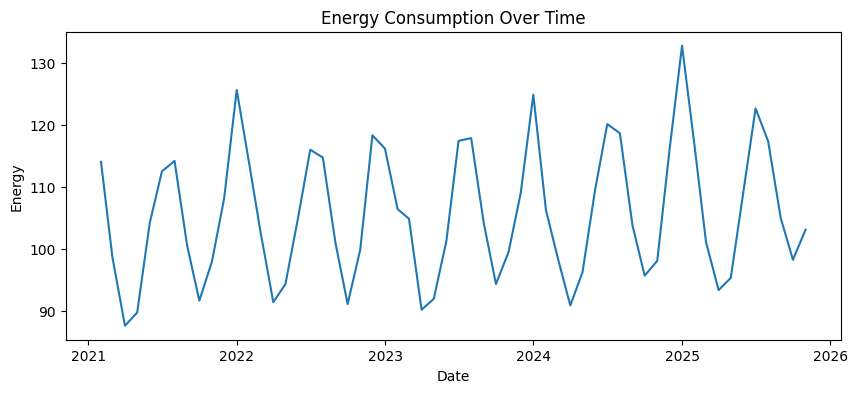

In [5]:
plt.figure(figsize=(10,4))
plt.plot(df['energy'])
plt.title("Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy")
plt.show()


In [6]:
train = df[:-12]   # all except last 12 months
test = df[-12:]


In [7]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train, order=(2,1,2))
arima_result = arima.fit()

arima_forecast = arima_result.forecast(steps=12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [8]:
from prophet import Prophet

prophet_df = df.reset_index()
prophet_df.columns = ['ds', 'y']

model = Prophet()
model.fit(prophet_df[:-12])

future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

prophet_forecast = forecast['yhat'][-12:].values


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [9]:
df_feat = df.reset_index()
df_feat['month'] = df_feat['DATE'].dt.month
df_feat['year'] = df_feat['DATE'].dt.year

X = df_feat[['month', 'year']]
y = df_feat['energy']

X_train, X_test = X[:-12], X[-12:]
y_train, y_test = y[:-12], y[-12:]


In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

xgb_forecast = xgb.predict(X_test)


In [11]:
def evaluate(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(test['energy'], arima_forecast, "ARIMA")
evaluate(test['energy'], prophet_forecast, "Prophet")
evaluate(test['energy'], xgb_forecast, "XGBoost")


ARIMA -> MAE: 6.83, RMSE: 8.51
Prophet -> MAE: 5.12, RMSE: 6.76
XGBoost -> MAE: 3.65, RMSE: 4.74


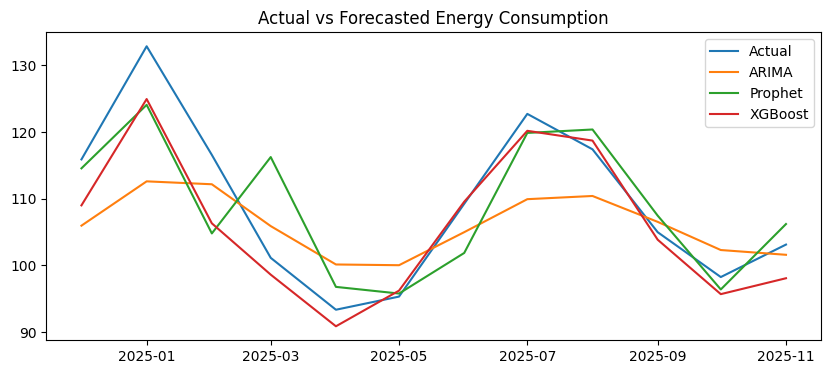

In [12]:
plt.figure(figsize=(10,4))
plt.plot(test.index, test['energy'], label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA')
plt.plot(test.index, prophet_forecast, label='Prophet')
plt.plot(test.index, xgb_forecast, label='XGBoost')
plt.legend()
plt.title("Actual vs Forecasted Energy Consumption")
plt.show()


## Conclusion
ARIMA, Prophet, and XGBoost were used to forecast energy
consumption. Prophet and XGBoost captured long-term
patterns effectively, while ARIMA performed well for
short-term forecasting.

